In [1]:
from GS_PGDS_Interval_Tensor import GS_PGDS_tensor
from tqdm.auto import tqdm
import torch
%load_ext autoreload
%autoreload 2

# The easiest situation: deep=1

In [4]:
V=12
T=300
sys = torch.zeros(T, V)
high_value = 50
low_value = 0
############# Stage 1 #############
sys[0:100, 0:4] = torch.poisson(high_value*torch.ones(100,4))        # 1st community
############# Stage 2 #############
sys[100:200, 4:8] = torch.poisson(high_value*torch.ones(100,4))        # 2st community
############# Stage 3 #############
sys[200:300, 8:12] = torch.poisson(high_value*torch.ones(100,4))        # 3st community

burnin = 60
maxiter = 20
params = {
'tau': 0.1,
'alpha0': 1.,
'epsilon_lam': 1,
'stationary': True
}
params['data'] = sys
params['K'] = 12
params['S'] = 60

gs_pgds = GS_PGDS_tensor(**params)
esti_steady = []
transition_steady = []
# design phi we could get correct estimation of intensity under K=3
gs_pgds.phi[0][:,:] = 0.
gs_pgds.phi[0][0:4,0:4] = 0.25
gs_pgds.phi[0][4:8,4:8] = 0.25
gs_pgds.phi[0][8:12,8:12] = 0.25
gs_pgds.pi  = torch.tile(gs_pgds.phi[0], (params['S'],1,1)) # torch.tile的对象必须是tensor
gs_pgds.pit = torch.tile(gs_pgds.phi[0], (T,1,1))
#gs_pgds.D   = torch.ones(gs_pgds.K, gs_pgds.K)*10
for iter in tqdm(range(burnin+maxiter)):
    gs_pgds.sample_n()
    gs_pgds.sample_l()
    gs_pgds.sample_the()
    gs_pgds.sample_lam()
    gs_pgds.sample_delt()
    gs_pgds.sample_beta()
    gs_pgds.sample_phi()
    gs_pgds.sample_pi()
    gs_pgds.sample_eta()
    gs_pgds.sample_tilde_lskk()
    gs_pgds.sample_Z()
    gs_pgds.sample_D()
    gs_pgds.sample_dpgm()

    if iter > burnin:
        esti_temp = gs_pgds.phi[0] @ torch.diag(gs_pgds.lam) @ (gs_pgds.the).T @ torch.diag(gs_pgds.delt)
        esti_steady.append(esti_temp.clone())
        transition_steady.append(gs_pgds.pi.clone())

  0%|          | 0/80 [00:00<?, ?it/s]

sample_n took 0.6603 seconds
sample_l took 1.4177 seconds
sample_the took 0.0191 seconds
sample_lam took 0.0004 seconds
sample_delt took 0.0002 seconds
sample_beta took 0.0001 seconds
sample_phi took 0.0021 seconds
sample_pi took 0.0890 seconds
sample_eta took 0.0014 seconds
sample_tilde_lskk took 0.0058 seconds
sample_Z took 1.1702 seconds
sample_D took 0.0088 seconds
sample_dpgm took 2.2888 seconds
sample_n took 0.5477 seconds
sample_l took 1.3418 seconds
sample_the took 0.0050 seconds
sample_lam took 0.0003 seconds
sample_delt took 0.0003 seconds
sample_beta took 0.0001 seconds
sample_phi took 0.0020 seconds
sample_pi took 0.0704 seconds
sample_eta took 0.0010 seconds
sample_tilde_lskk took 0.0269 seconds
sample_Z took 1.0264 seconds
sample_D took 0.0028 seconds
sample_dpgm took 2.1433 seconds
sample_n took 0.5342 seconds
sample_l took 1.2936 seconds
sample_the took 0.0128 seconds
sample_lam took 0.0003 seconds
sample_delt took 0.0003 seconds
sample_beta took 0.0001 seconds
sample_p

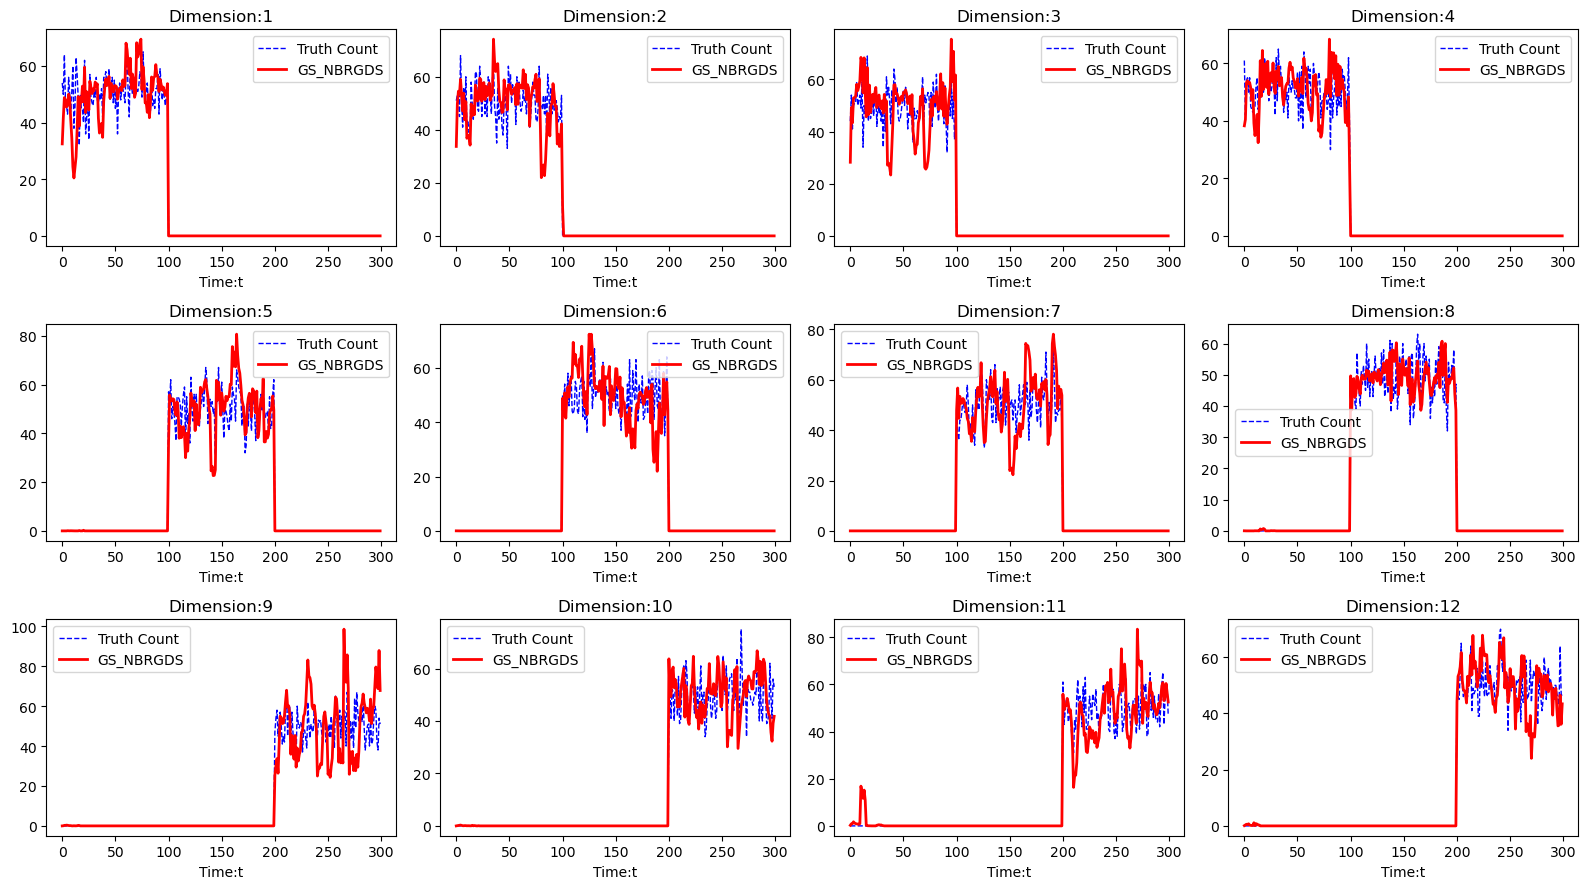

In [5]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
esti_steady = torch.stack(esti_steady)
esti_mean = torch.mean(esti_steady, axis = 0)
fig, axs = plt.subplots(3,4, figsize=(16,9))
for i, ax in enumerate(axs.flatten()):
    ax.plot(sys[:,i], color = 'blue', linewidth = 1, linestyle = '--', label = 'Truth Count')
    ax.plot(esti_mean[i], color = 'red', linewidth = 2, label = 'GS_NBRGDS')
    ax.set_title(f'Dimension:{i+1}')
    ax.set_xlabel('Time:t')
    ax.legend()
plt.tight_layout()
plt.show()

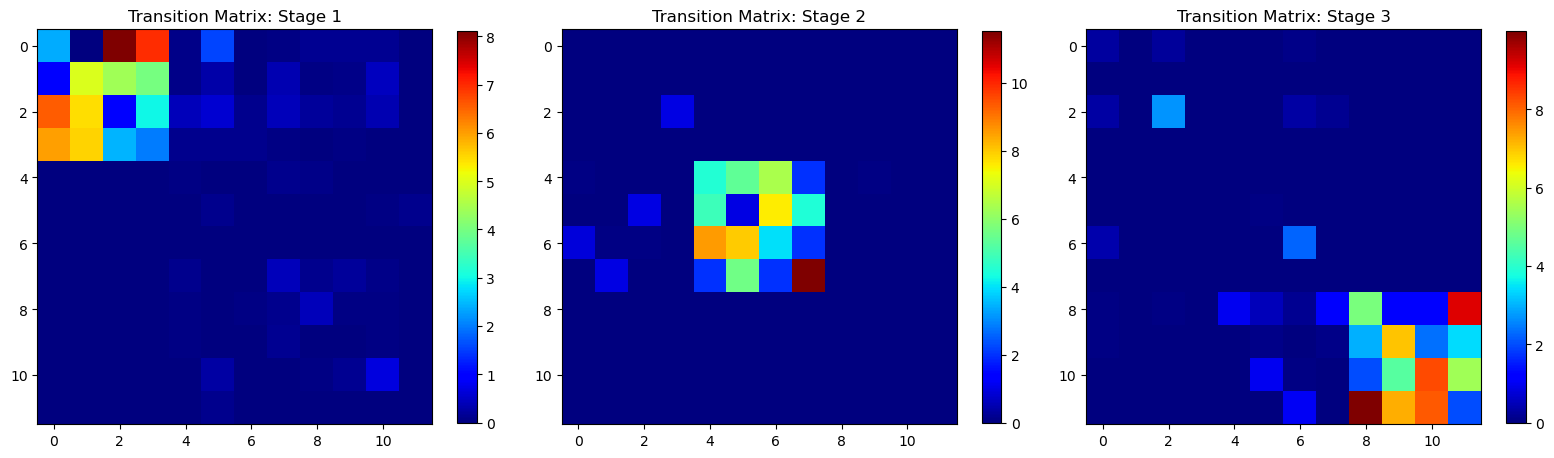

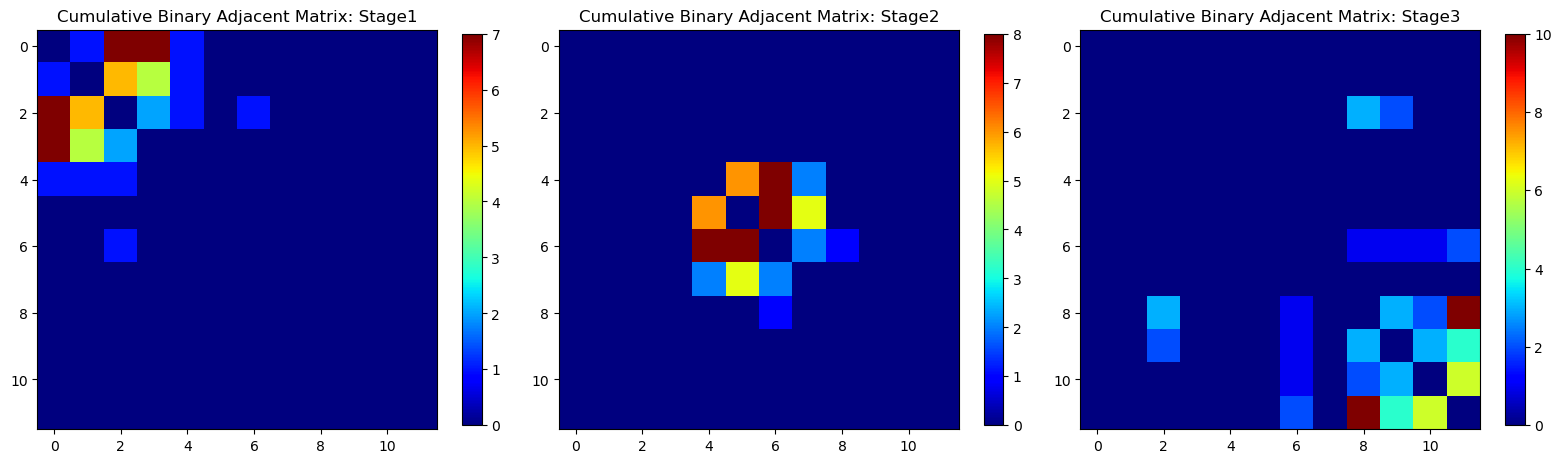

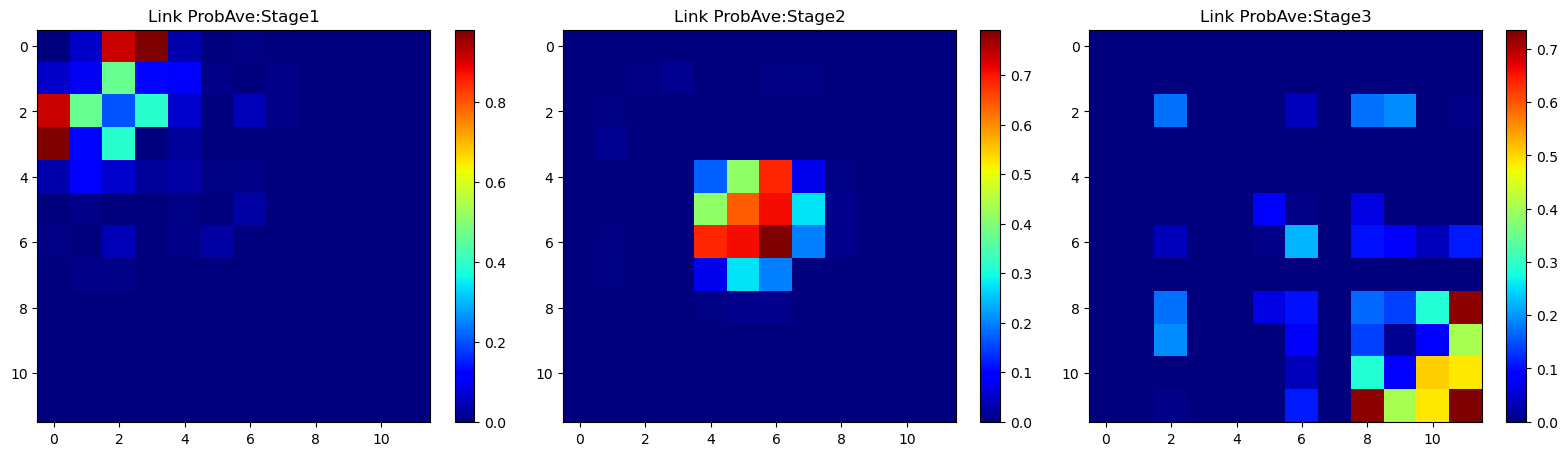

In [8]:
%matplotlib inline
#transition_steady = torch.stack(transition_steady) 
transition_mean = torch.mean(transition_steady, axis = 0)
fig, axs = plt.subplots(1, 3, figsize=(16, 9))
for i, ax in enumerate(axs.flatten()):
    if i == 0:
        transition_sum = np.sum(np.array(transition_mean)[4:20], axis = 0)
    else:
        transition_sum = np.sum(np.array(transition_mean)[i*20: i*20+20], axis=0)
    im = ax.imshow(transition_sum, cmap='jet')
    ax.set_title(f'Transition Matrix: Stage {i+1}')
    # Add colorbar to each subplot
    cbar = plt.colorbar(im, ax=ax, shrink=0.45)
plt.tight_layout()
plt.show()

%matplotlib inline
fig, axs = plt.subplots(1,3, figsize=(16,9))
for i,ax in enumerate(axs):
    if i == 0:
        Z = torch.sum(gs_pgds.Z[4:20], axis = 0)
    else:
        Z = torch.sum(gs_pgds.Z[i*20:i*20+20], axis = 0)
    im = ax.imshow(Z+Z.T, cmap='jet')
    cbar = plt.colorbar(im, ax=ax, shrink=0.45)
    ax.set_title(f'Cumulative Binary Adjacent Matrix: Stage{i+1}')
plt.tight_layout()
plt.show()

%matplotlib inline
fig, axs = plt.subplots(1,3, figsize = (16,9))
for i in range(3):
    if i == 0:
        ProbAve = torch.mean(gs_pgds.ProbAve[4:20], axis = 0)
    else:
        ProbAve = torch.mean(gs_pgds.ProbAve[i*20:i*20+20], axis = 0) 
    im = axs[i].imshow(ProbAve + ProbAve.T, cmap='jet')
    axs[i].set_title(f'Link ProbAve:Stage{i+1}')
    cbar = plt.colorbar(im, ax = axs[i], shrink=0.45)
plt.tight_layout()
plt.show()

# Deep=2, mode 1 = 60, mode 2 = 60, time = 300, interval = 3, community=20*20

In [30]:
# generate sysnthetic data
T = 300
S = 3
high_value = 50
sys = torch.zeros(T,60,60)
sys[0:100, 0:20, 0:20] = torch.poisson(high_value*torch.ones(100,20,20))
sys[100:200, 20:40, 20:40] = torch.poisson(high_value*torch.ones(100,20,20))
sys[200:300, 40:60, 40:60] = torch.poisson(high_value*torch.ones(100,20,20))

In [36]:
# run model
burnin = 60
maxiter = 20
params = {
'tau': 0.1,
'alpha0': 10.,
'epsilon_lam': 1.,
'stationary': True,
'data' : sys,
'K' : 30, # latent components
'S' : 60 # sub-stages
}

gs_pgds = GS_PGDS_tensor(**params)
esti_steady = []
transition_steady = []
# phi should be a list
gs_pgds.phi[0][:,:] = 0.
gs_pgds.phi[0][0:20,0:10] = 1/20
gs_pgds.phi[0][20:40,10:20] = 1/20
gs_pgds.phi[0][40:60,20:30] = 1/20
gs_pgds.phi[1][:,:] = 0.
gs_pgds.phi[1][0:20,0:10] = 1/20
gs_pgds.phi[1][20:40,10:20] = 1/20
gs_pgds.phi[1][40:60,20:30] = 1/20

initial_pi = torch.zeros(30,30)
initial_pi[0:10, 0:10] = 1/10
initial_pi[10:20, 10:20] = 1/10
initial_pi[20:30, 20:30] = 1/10
gs_pgds.pi  = torch.tile(initial_pi, (params['S'],1,1)) # torch.tile的对象必须是tensor
gs_pgds.pit = torch.tile(initial_pi, (T,1,1))
gs_pgds.D   = torch.ones(gs_pgds.K, gs_pgds.K)*10
for iter in tqdm(range(burnin+maxiter)):
    gs_pgds.sample_n()
    gs_pgds.sample_l()
    gs_pgds.sample_the()
    gs_pgds.sample_lam()
    gs_pgds.sample_delt()
    gs_pgds.sample_beta()
    gs_pgds.sample_phi()
    gs_pgds.sample_pi()
    gs_pgds.sample_eta()
    gs_pgds.sample_tilde_lskk()
    gs_pgds.sample_Z()
    gs_pgds.sample_D()
    gs_pgds.sample_dpgm()

    if iter > burnin:
        transition_steady.append(gs_pgds.pi.clone())

  0%|          | 0/80 [00:00<?, ?it/s]

sample_n took 30.2699 seconds
sample_l took 2.1927 seconds
sample_the took 0.0020 seconds
sample_lam took 0.0000 seconds
sample_delt took 0.0090 seconds
sample_beta took 0.0000 seconds
sample_phi took 0.0448 seconds
sample_pi took 0.1595 seconds
sample_eta took 0.0155 seconds
sample_tilde_lskk took 0.0199 seconds
sample_Z took 3.9827 seconds
sample_D took 0.0010 seconds
sample_dpgm took 4.8242 seconds
sample_n took 32.6402 seconds
sample_l took 2.1472 seconds
sample_the took 0.0015 seconds
sample_lam took 0.0010 seconds
sample_delt took 0.0020 seconds
sample_beta took 0.0000 seconds
sample_phi took 0.0526 seconds
sample_pi took 0.1594 seconds
sample_eta took 0.0010 seconds
sample_tilde_lskk took 1.1828 seconds
sample_Z took 4.1214 seconds
sample_D took 0.0010 seconds
sample_dpgm took 5.3351 seconds
sample_n took 30.6911 seconds
sample_l took 2.2971 seconds
sample_the took 0.0010 seconds
sample_lam took 0.0010 seconds
sample_delt took 0.0010 seconds
sample_beta took 0.0000 seconds
sampl

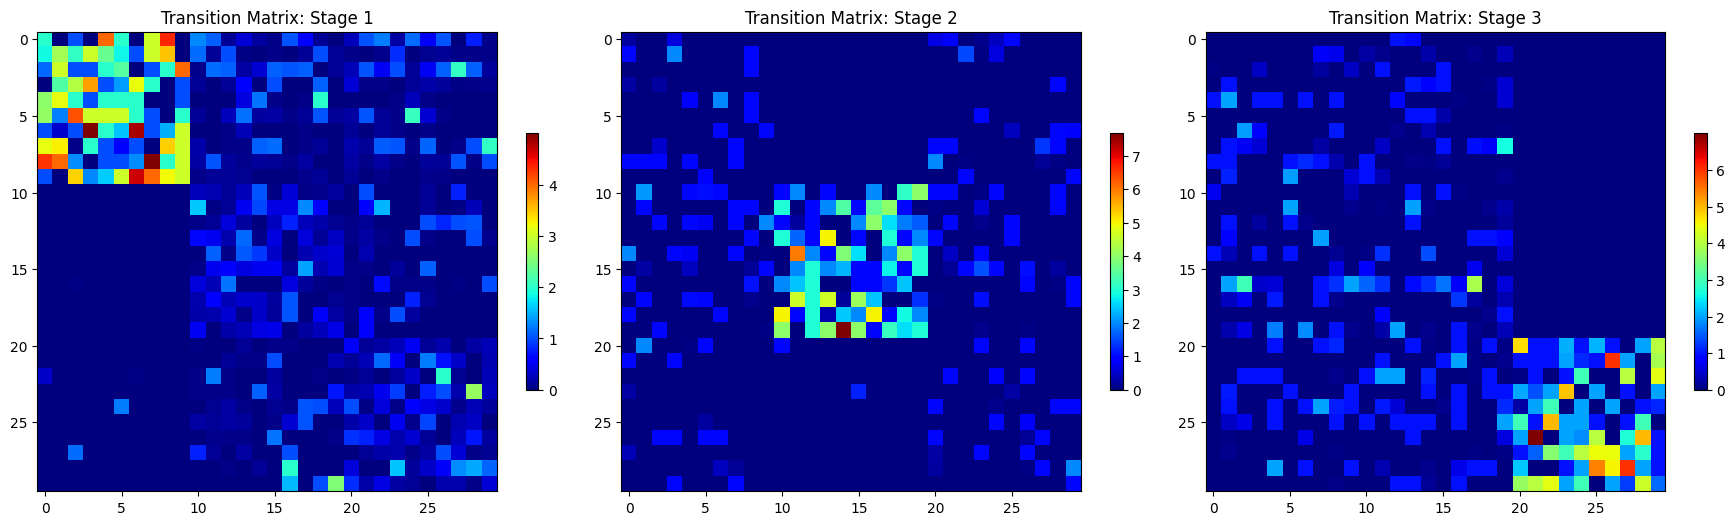

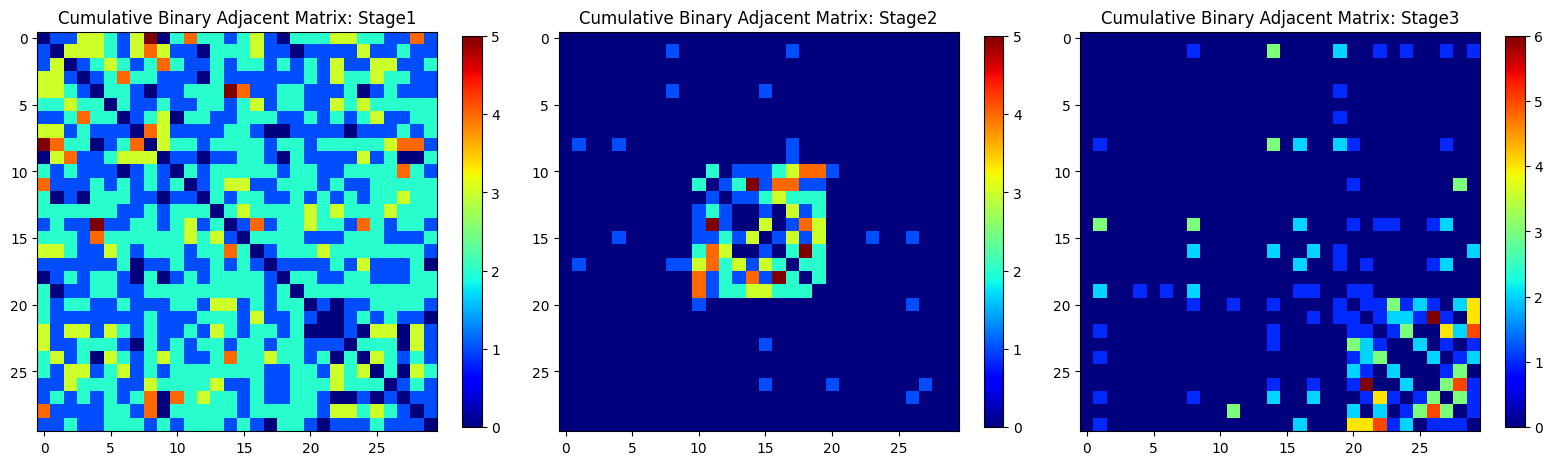

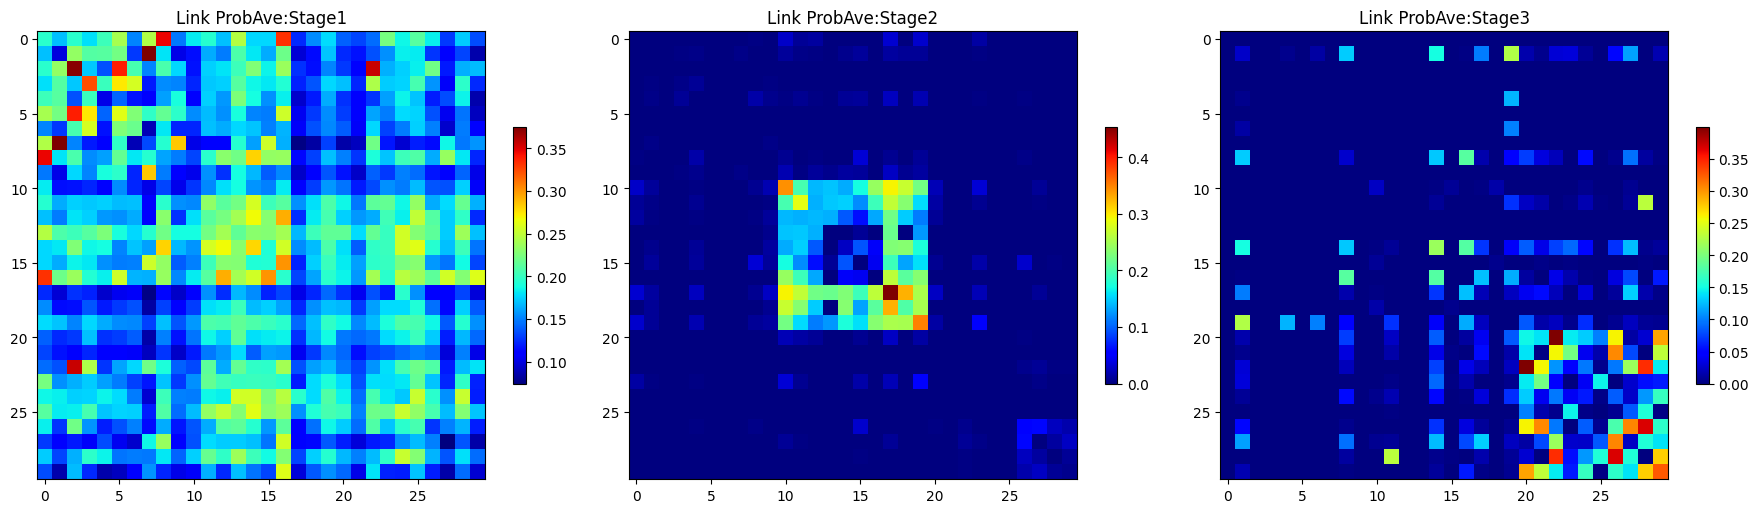

In [33]:
%matplotlib inline
transition_steady = torch.stack(transition_steady) 
transition_mean = torch.mean(transition_steady, axis = 0)
fig, axs = plt.subplots(1, 3, figsize=(18,6))
for i, ax in enumerate(axs.flatten()):
    transition_sum = np.sum(np.array(transition_mean)[i*20: i*20+20], axis=0)
    im = ax.imshow(transition_sum, cmap='jet')
    ax.set_title(f'Transition Matrix: Stage {i+1}')
    # Add colorbar to each subplot
    cbar = plt.colorbar(im, ax=ax, shrink=0.45)
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1,3, figsize=(16,9))
for i,ax in enumerate(axs):
    Z = torch.sum(gs_pgds.Z[i*20:i*20+20], axis=0)
    im = ax.imshow(Z+Z.T, cmap='jet')
    cbar = plt.colorbar(im, ax=ax, shrink=0.45)
    ax.set_title(f'Cumulative Binary Adjacent Matrix: Stage{i+1}')
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1,3, figsize = (18,6))
for i in range(3):
    ProbAve=torch.mean(gs_pgds.ProbAve[i*20:i*20+20], axis = 0) 
    im = axs[i].imshow(ProbAve + ProbAve.T, cmap='jet')
    axs[i].set_title(f'Link ProbAve:Stage{i+1}')
    cbar = plt.colorbar(im, ax = axs[i], shrink=0.45)
plt.tight_layout()
plt.show()

# Complex case

In [9]:
# complex case
# generate sysnthetic data
T = 1000
S = 5
high_value = 50
sys = torch.zeros(T,100,100)
# interval 1
sys[0:50, 0:20, 0:20] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[50:100, 80:100, 80:100] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[100:150, 0:20, 0:20] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[150:200, 80:100, 80:100] = torch.poisson(high_value * torch.ones(50, 20, 20))
# interval 2 
sys[200:250, 20:40, 20:40] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[250:300, 60:80, 60:80] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[300:350, 20:40, 20:40] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[350:400, 60:80, 60:80] = torch.poisson(high_value * torch.ones(50, 20, 20))
# interval 3
sys[400:450, 0:20,0:20] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[400:450, 20:40,20:40] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[450:500, 60:80,60:80] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[450:500, 80:100,80:100] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[500:550, 0:20,0:20] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[500:550, 20:40,20:40] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[550:600, 60:80,60:80] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[550:600, 80:100,80:100] = torch.poisson(high_value * torch.ones(50, 20, 20))
# interval 4
sys[600:800, 20:40,20:40] = torch.poisson(high_value * torch.ones(200, 20, 20))
sys[600:800, 60:80,60:80] = torch.poisson(high_value * torch.ones(200, 20, 20))
# interval 5
sys[800:1000, 40:60, 40:60] = torch.poisson(high_value * torch.ones(200, 20, 20))

In [10]:
# run model
burnin = 60
maxiter = 20
params = {
'tau': 1,
'alpha0': 10.,
'epsilon_lam': 1.,
'stationary': True,
'data' : sys,
'K' : 50, # latent components
'S' : 200 # sub-stages
}

gs_pgds = GS_PGDS_tensor(**params)
esti_steady = []
transition_steady = []
# phi should be a list
gs_pgds.phi[0][:,:] = 0.
gs_pgds.phi[0][0:20,0:10] = 1/20
gs_pgds.phi[0][20:40,10:20] = 1/20
gs_pgds.phi[0][40:60,20:30] = 1/20
gs_pgds.phi[0][60:80,30:40] = 1/20
gs_pgds.phi[0][80:100,40:50] = 1/20
gs_pgds.phi[1][:,:] = 0.
gs_pgds.phi[1][0:20,0:10] = 1/20
gs_pgds.phi[1][20:40,10:20] = 1/20
gs_pgds.phi[1][40:60,20:30] = 1/20
gs_pgds.phi[1][60:80,30:40] = 1/20
gs_pgds.phi[1][80:100,40:50] = 1/20

initial_pi = torch.zeros(50,50)
initial_pi[0:10, 0:10] = 1/10
initial_pi[10:20, 10:20] = 1/10
initial_pi[20:30, 20:30] = 1/10
initial_pi[30:40, 30:40] = 1/10
initial_pi[40:50, 40:50] = 1/10
gs_pgds.pi  = torch.tile(initial_pi, (params['S'],1,1)) # torch.tile的对象必须是tensor
gs_pgds.pit = torch.tile(initial_pi, (T,1,1))
gs_pgds.D   = torch.ones(gs_pgds.K, gs_pgds.K)*10
for iter in tqdm(range(burnin+maxiter)):
    gs_pgds.sample_n()
    gs_pgds.sample_l()
    gs_pgds.sample_the()
    gs_pgds.sample_lam()
    gs_pgds.sample_delt()
    gs_pgds.sample_beta()
    gs_pgds.sample_phi()
    gs_pgds.sample_pi()
    gs_pgds.sample_eta()
    gs_pgds.sample_tilde_lskk()
    gs_pgds.sample_Z()
    gs_pgds.sample_D()
    gs_pgds.sample_dpgm()

    if iter > burnin:
        transition_steady.append(gs_pgds.pi.clone())

  0%|          | 0/80 [00:00<?, ?it/s]

sample_n took 259.6399 seconds
sample_l took 18.3729 seconds
sample_the took 0.0091 seconds
sample_lam took 0.0005 seconds
sample_delt took 0.0213 seconds
sample_beta took 0.0002 seconds
sample_phi took 1.7360 seconds
sample_pi took 1.2020 seconds
sample_eta took 0.0043 seconds
sample_tilde_lskk took 0.2819 seconds
sample_Z took 58.5098 seconds
sample_D took 0.0139 seconds
sample_dpgm took 97.9906 seconds
sample_n took 274.2151 seconds
sample_l took 25.0869 seconds
sample_the took 0.0101 seconds
sample_lam took 0.0004 seconds
sample_delt took 0.0215 seconds
sample_beta took 0.0002 seconds
sample_phi took 1.6199 seconds
sample_pi took 1.7125 seconds
sample_eta took 0.0046 seconds


: 